In [54]:
# Python style is to put your library imports all at the top (see the PEP8 style guide)

import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

# Here are the two statsmodels apis. I prefer the formula api, it operates on
# pandas dataframes and you can specify a formula directly. The regular
# sm api can also generate models, but you need to construct the design matrix yourself
# sm is good for production, smf is good for exploration


import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.graphics as smg

from statsmodels.stats.outliers_influence import ( 
    variance_inflation_factor as VIF)

from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess


from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize, poly




In [3]:
dir()

['In',
 'MS',
 'Out',
 'VIF',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'anova_lm',
 'exit',
 'get_ipython',
 'help',
 'load_data',
 'np',
 'open',
 'pd',
 'poly',
 'quit',
 'sm',
 'smf',
 'subplots',
 'summarize']

In [4]:
A = np.array([3,5,101])
dir(A)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '_

In [11]:
A.cumsum()

array([  3,   8, 109])

In [12]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='str')

In [ ]:
# Let us make a model that says median housing prices (medv) is proportional to 
# lstat (percent of households with low socioeconomic status)

# There are two ways to do this, as we have said. The simplest is with the statsmodels formula api:

medv_simp_reg = smf.ols('medv ~ lstat',data=Boston).fit()
medv_simp_reg.summary()

#medv_simp_reg = smf.ols('medv ~ lstat',data=Boston).fit(cov_type='HC3')




<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           5.08e-88
Time:                        16:14:50   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
# Now, how to do it using the sm api

# We need to construct the design matrix X explicitly. This includes adding a constant vector of ones
# as a feature (check the lecture notes to see how I included this in X)

X = pd.DataFrame({'intercept':np.ones(Boston.shape[0]),
                'lstat':Boston['lstat']})

y = Boston['medv']

X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


In [19]:
# I have no idea why it is capital OLS in statsmodels and lowercase in formulas...


# Super common pitfall when using statsmodels regular api is to forget the intercept. As above you must manually
# include it. This is NOT the case with the formulas API
medv_reg_v2_model = sm.OLS(y,X)
medv_reg_v2 = medv_reg_v2_model.fit()

medv_reg_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           5.08e-88
Time:                        16:23:05   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# There is another function from the ISLP package which is handy for looking at the results of these models

# I personally hate the obsession with P values and null hypothesis significance testing. 

summarize(medv_reg_v2)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [22]:
medv_reg_v2.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [21]:
# The ISLP package has a function called ModelSpec which imitates the transform function API of 
# sklearn. Indeed one of the advantages of the plain statsmodels over the formulas is that it interfaces much
# more naturally with sklearn pipelines, which allows you to better fit statsmodels objects into a production-like
# workflow


# the ModelSpec function was imported with name MS

# We can apply it to a dataframe to create a model design matrix

design = MS(['lstat'])

design.fit(Boston)

X = design.transform(Boston)

# or even

X = design.fit_transform(Boston)

X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


In [23]:
# Suppose we want to use our fitted model to make predictions. We can do so using a similar 
# methodology to sklearn

new_df = pd.DataFrame({'lstat':[5, 10, 15]})

# We need to create an object similar to the design matrix in order to make predictions
newX = design.transform(new_df)

newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [25]:
new_predictions = medv_reg_v2.get_prediction(newX);
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [26]:
# Now, one of the key differences between sklearn and statsmodels is that there is much 
# support for uncertainty quantification, you can get uncertainty intervals/confidence 
# intervals surrounding the predictions

new_predictions.conf_int( alpha=0.05)


array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [ ]:
# Now for prediction intervals:

new_predictions.conf_int(obs=True, alpha=0.05)


# The difference here is that when obs=True it incorporates the natural variance in the dataset
# where might you actually observe a point, whereas when you don't specify it, the prediction is
# where the predicted regression line goes. That is why the interals become so much wider.

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [28]:
# You probably have some experience defining functions,
# Generally, if you are repeating code more than a few times
# you should consider whether that code would fit better
# within a function

# This function draw straight lines on graphs

# Note the *args and **kwargs arguments
# These allow you to pass unnamed and unnamed
# additional variables that are optional. In the
# context of this function, these are arguments that
# will be passed to ax.plot()

def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

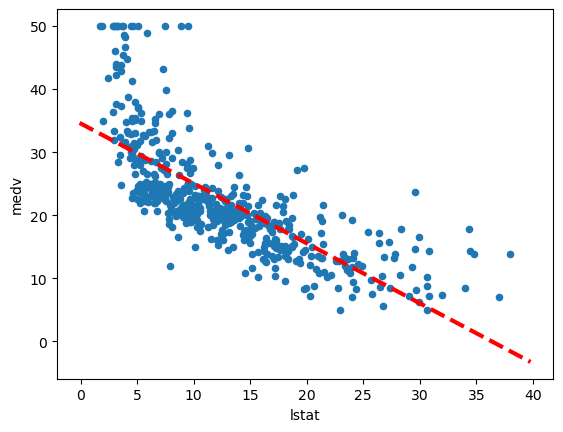

In [ ]:
# Here is a plot of the Boston data with our linear
# regression line drawn

# Notice that I needed to define the ax object, and that
# I passed first the unnamed and then the named arguments

ax = Boston.plot.scatter('lstat', 'medv')
abline(ax,
       medv_reg_v2.params.iloc[0],
       medv_reg_v2.params.iloc[1],
       'r--',
       linewidth=3)


# Note how there is a bit of an upward curve away from the
# regression line for low values of lstat. This is evidence of
# nonlinearity



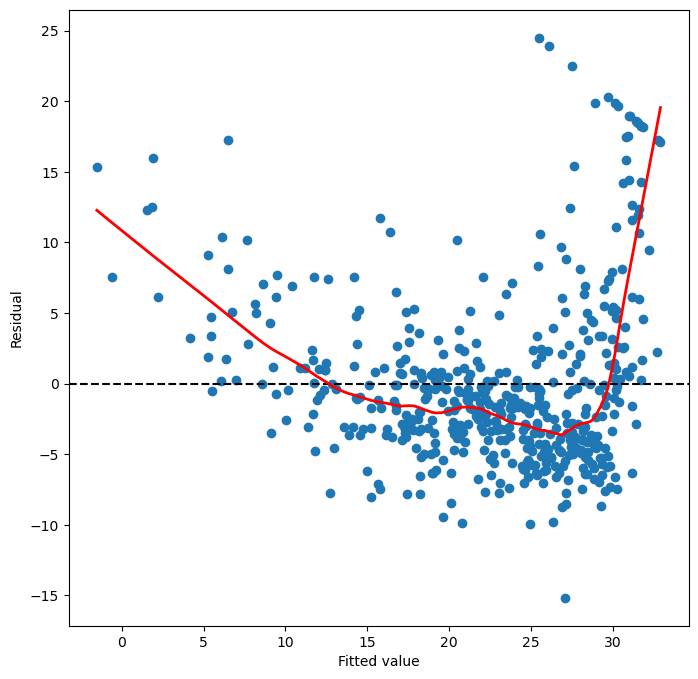

In [ ]:
# This fitted value plot shows the size of the errors as a 
# function of the fitted values

# resid stands for residuals and fittedvalues stands for
# the predictions on the data

# We can see from this plot some evidence of non-linearity
# namely that it is not evenly scattered around the black line

ax = subplots(figsize=(8,8))[1]
ax.scatter(medv_reg_v2.fittedvalues, medv_reg_v2.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');


# Here is the code which I used to draw a spline through the
# residuals to show the pattern I'm talking about:

# A linear relationship would have a horizontal line

smoothed = lowess(medv_reg_v2.resid, medv_reg_v2.fittedvalues, frac=0.2)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2)


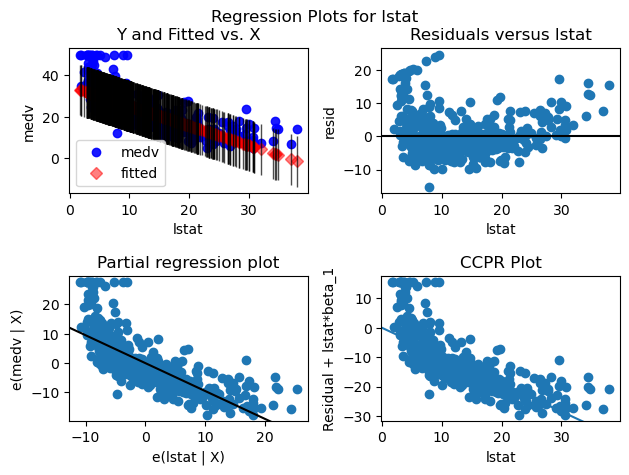

In [52]:
# Statsmodels has some basic builtin plotting routines
# which can be quick and convenient.A

# Notice the semicolon afterwards. This prevents the
# plot from appearing twice in a python notebook
# you could also achieve this by writing fig=sm...
# or by having some additional code after the graph
sm.graphics.plot_regress_exog(medv_reg_v2, 'lstat');

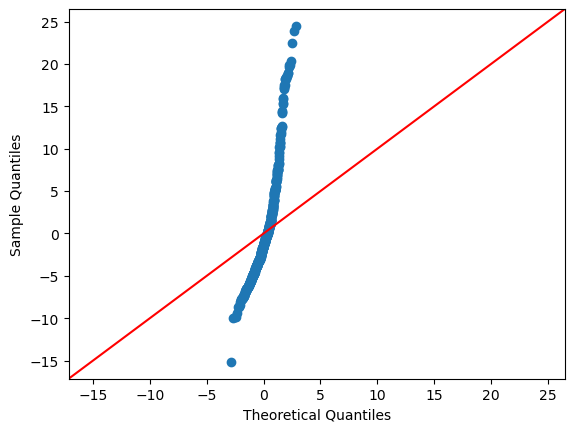

In [57]:
# More built ins, let's say you want to look at the residuals
# for normality (there are some built in tests for that)

fig = sm.qqplot(medv_reg_v2.resid, line='45')

In [ ]:
# We can again look at the summary object to see the Jarque-Bera
# value to determine if the residuals are actually normal

# BTW normal residuals are NOT required for you to use
# linear regression. It is a common misconception to 
# think there is a major problem if the residuals aren't
# normal. Normality is needed if you want to interpret
# a lot of the sample statistics though. There is a result
# called the Gauss-Markov theorem which says that the typical
# linear regression model is ideal for linear data in a 
# very wide variety of conditions. See this paper for more

# discussion: https://www.sciencedirect.com/science/article/abs/pii/S0895435617304857

# Needless to say, the extreme lack of normality here
# indicates a problem with the model (nonlinearity)
# which we can see by other means

medv_reg_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           5.08e-88
Time:                        09:21:53   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

np.int64(374)

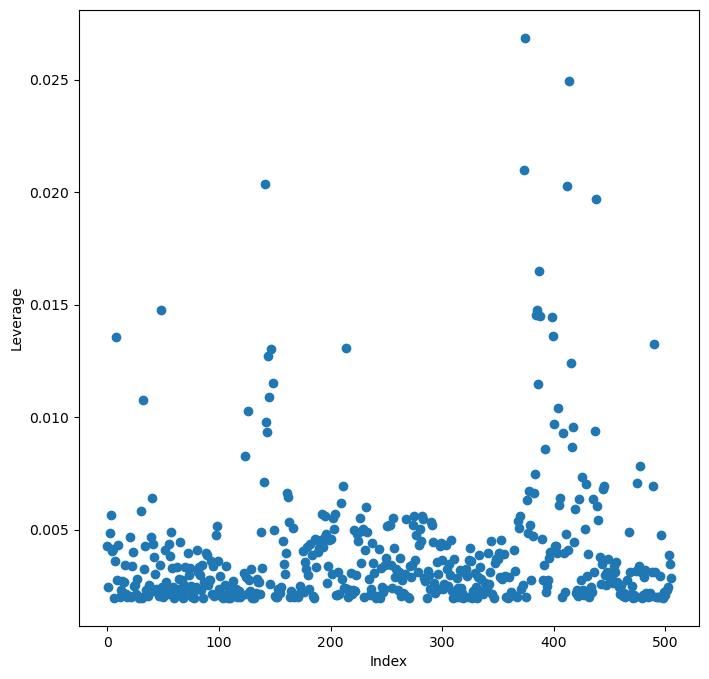

In [ ]:
# In Machine Learning (not just statistical modeling)
# it can be important to understand which observations
# have a big impact on the model. In linear regression
# this is measured by something called the influence

infl = medv_reg_v2.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

np.int64(374)

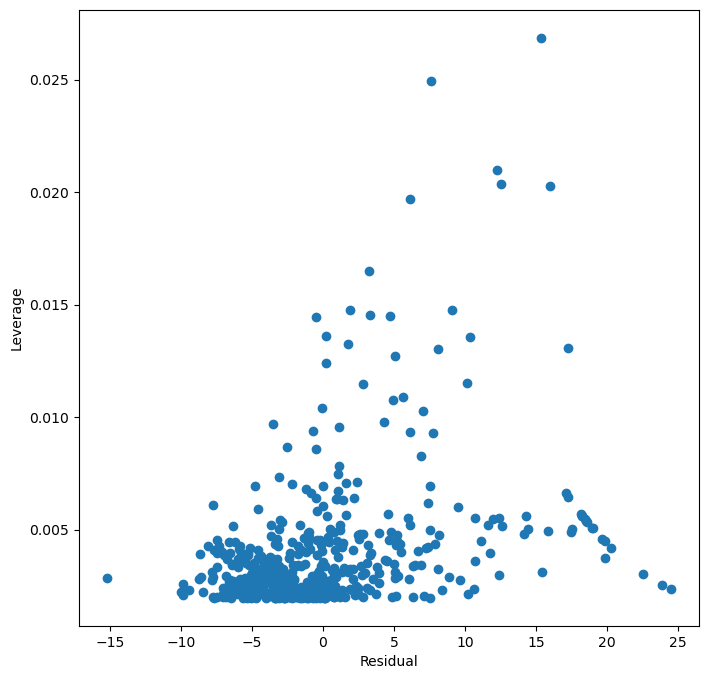

In [66]:
# Generally, high leverage is bad if it coincides with
# high residuals. We can see that here. High leverage
# means that the model wants to alter the parameters as
# much as possible to reduce the residual of that point.
# If it can't happen and the residual remains high it 
# suggests a problem



infl = medv_reg_v2.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(medv_reg_v2.resid, infl.hat_matrix_diag)
ax.set_xlabel('Residual')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [67]:
# It is very similar to include multiple variables in the 
# model

X = MS(['lstat', 'age']).fit_transform(Boston)
multiple_reg = sm.OLS(y, X)
multiple_reg_results = multiple_reg.fit()
summarize(multiple_reg_results)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [68]:
# You can do it using formulas as well

multiple_reg_form = smf.ols('medv ~ lstat + age',Boston).fit()
summarize(multiple_reg_form)

,coef,std err,t,P>|t|
Intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [69]:
# There are some helper tools which let us avoid having 
# to type out too many variable names

# column drop gives us a list of columns minus the ones
# we don't want to use:

terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age',
       'dis', 'rad', 'tax', 'ptratio', 'lstat'],
      dtype='str')

In [71]:
# We can use this to create a very "full" model

X = MS(terms).fit_transform(Boston)
model_full = sm.OLS(y, X)
results_full = model_full.fit()
results_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          2.23e-133
Time:                        09:34:30   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.6173      4.936      8.431      0.000      31.919      51.316
crim          -0.1214      0.033     -3.678      0.000      -0.186      -0.057
zn             0.0470      0.014      3.384      0.001       0.020       0.074
indus          0.0135      0.062      0.217      0.829      -0.109       0.136
chas           2.8400      0.870      3.264      0.001       1.131       4.549
nox          -18.7580      3.851     -4.870      0.000     -26.325     -11.191
rm             3.6581      0.420      8.705      0.000       2.832       4.484
age            0.0036      0.013      0.271      0.787      -0.023       0.030
dis           -1.4908      0.202     -7.394      0.000      -1.887      -1.095
rad            0.2894      0.067      4.325      0.000       0.158       0.421
tax           -0.0127      0.004     -3.337      0.001      -0.020      -0.005
ptratio       -0.9375      0.132     -7.091      0.000      -1.197      -0.678
lstat         -0.5520      0.051    -10.897      0.000      -0.652      -0.452
==============================================================================
Omnibus:                      171.096   Durbin-Watson:                   1.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.937
Skew:                           1.477   Prob(JB):                    6.90e-155
Kurtosis:                       7.995   Cond. No.                     1.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# We can discard some predictors

# Here dropping the two additional columns, age and indus
# led to an improved AIC score, and thus 
# potentially improved out of sample accuracy

terms =  Boston.columns.drop(['medv','age','indus'])

X = MS(terms).fit_transform(Boston)
model_drop = sm.OLS(y, X)
results_drop = model_drop.fit()
results_drop.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     136.8
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          1.73e-135
Time:                        09:36:28   Log-Likelihood:                -1505.0
No. Observations:                 506   AIC:                             3032.
Df Residuals:                     495   BIC:                             3078.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.4517      4.903      8.454      0.000      31.818      51.086
crim          -0.1217      0.033     -3.696      0.000      -0.186      -0.057
zn             0.0462      0.014      3.378      0.001       0.019       0.073
chas           2.8719      0.863      3.329      0.001       1.177       4.567
nox          -18.2624      3.565     -5.122      0.000     -25.267     -11.258
rm             3.6730      0.409      8.978      0.000       2.869       4.477
dis           -1.5160      0.188     -8.078      0.000      -1.885      -1.147
rad            0.2839      0.064      4.440      0.000       0.158       0.410
tax           -0.0123      0.003     -3.608      0.000      -0.019      -0.006
ptratio       -0.9310      0.130     -7.138      0.000      -1.187      -0.675
lstat         -0.5465      0.047    -11.519      0.000      -0.640      -0.453
==============================================================================
Omnibus:                      172.594   Durbin-Watson:                   1.074
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              725.971
Skew:                           1.486   Prob(JB):                    2.28e-158
Kurtosis:                       8.060   Cond. No.                     1.13e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""